In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


In [43]:
print("Loading data...")
covtype = fetch_covtype()
X,y = covtype.data, covtype.target - 1  # Labels are 1-7, convert to 0-6

Loading data...


In [44]:
# Use subset for faster training (still 100k samples)
X = X[:10000]
y = y[:10000]

print(f"Dataset : {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))}")
print("This is HIGH DIMENSIONAL - easy to overfit without regularization")

Dataset : 10000 samples, 54 features, 7
This is HIGH DIMENSIONAL - easy to overfit without regularization


In [45]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print(f"Total shape of X : {X.shape}")
print(f"Total shape of y : {y.shape}")
print("")
print(f"Shape of X_train : {X_train.shape}")
print(f"Shape of y_train : {y_train.shape}")
print()
print(f"Shape of X_val : {X_val.shape}")
print(f"Shape of y_val : {y_val.shape}")
print()
print(f"Shape of X_test : {X_test.shape}")
print(f"Shape of y_test : {y_test.shape}")

# Normalize (Critical for high-dimensional data)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val, X_test = scaler.transform(X_val), scaler.transform(X_test)

print('Data has been scaled')

# COnvert to tensor
print("Converting to Pytorch tensors")
X_train_t = torch.FloatTensor(X_train).to(device)
X_val_t   = torch.FloatTensor(X_val).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
y_val_t   = torch.LongTensor(y_val).to(device)
y_test_t  = torch.LongTensor(y_test).to(device)

# create datasets
print("now creating datasets")
train_dataset = TensorDataset(X_train_t, 
                              y_train_t)

val_dataset   = TensorDataset(X_val_t,
                              y_val_t)

test_dataset  = TensorDataset(X_test_t,
                              y_test_t)

print()
print(f"Train dataset but now is TensorDataset and TensorDataType (This is the X_train ): {train_dataset.tensors[0].size()}")
print(f"Train dataset but now is TensorDataset and TensorDataType (This is the y_train ): {train_dataset.tensors[1].size()}")
print()
print(f"Val dataset but now is TensorDataset and TensorDataType (This is the X_val ): {val_dataset.tensors[0].size()}")
print(f"Val dataset but now is TensorDataset and TensorDataType (This is the y_val ): {val_dataset.tensors[1].size()}")
print()
print(f"Test dataset but now is TensorDataset and TensorDataType (This is the X_test ): {test_dataset.tensors[0].size()}")
print(f"Test dataset but now is TensorDataset and TensorDataType (This is the y_test ): {test_dataset.tensors[1].size()}")

# Create loaders
print("")
print("Now creating DataLoaders for train and val")
train_loader = DataLoader(train_dataset,
                          batch_size=512,
                          shuffle=True)

val_loader = DataLoader(val_dataset,
                          batch_size=512,
                          shuffle=False)


Total shape of X : (10000, 54)
Total shape of y : (10000,)

Shape of X_train : (7000, 54)
Shape of y_train : (7000,)

Shape of X_val : (1500, 54)
Shape of y_val : (1500,)

Shape of X_test : (1500, 54)
Shape of y_test : (1500,)
Data has been scaled
Converting to Pytorch tensors
now creating datasets

Train dataset but now is TensorDataset and TensorDataType (This is the X_train ): torch.Size([7000, 54])
Train dataset but now is TensorDataset and TensorDataType (This is the y_train ): torch.Size([7000])

Val dataset but now is TensorDataset and TensorDataType (This is the X_val ): torch.Size([1500, 54])
Val dataset but now is TensorDataset and TensorDataType (This is the y_val ): torch.Size([1500])

Test dataset but now is TensorDataset and TensorDataType (This is the X_test ): torch.Size([1500, 54])
Test dataset but now is TensorDataset and TensorDataType (This is the y_test ): torch.Size([1500])

Now creating DataLoaders for train and val


In [46]:
# Creating network for HIGH Dimensional Dataset
class ANN(nn.Module):
    def __init__(self, input_dim, dropout_rate = 0.5):
        super(ANN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout_rate),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(dropout_rate),

            nn.Linear(64, 7)
        )

    def forward(self, x):
        return self.net(x)
    
# Early stopping
class EarlyStopping:
    def __init__(self, patience=15, min_delta = 0.0001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_model = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model = model.state_dict().copy()
        
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_model = model.state_dict().copy()
            self.counter = 0

# Training Function
def train_model(name, weight_decay, dropout_rate, lr=0.001, epochs=100):
    model = ANN(input_dim=X_train.shape[1], dropout_rate=dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr = lr, weight_decay=weight_decay)
    early_stopping = EarlyStopping(patience=15)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []


    print(f"\nTraining: {name}")
    print(f"weight_decay={weight_decay}, dropout={dropout_rate}, lr={lr}")

    for epoch in range(epochs):
        # Training Mode
        model.train()
        train_loss, correct, total = 0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

        avg_train_loss = train_loss / len(train_loader)
        train_acc = 100 * correct / total
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)
        

        # Validation
        val_loss, correct, total = 0,0,0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        val_acc      = 100 * correct / total
        val_losses.append(avg_val_loss)
        val_accs.append(val_acc)

        if (epoch+1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d} | Train: {avg_train_loss:.4f}/{train_acc:.2f}% | Val: {avg_val_loss:.4f}/{val_acc:.2f}%")
        
        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print(f"Early stopped at epoch {epoch+1}")
            model.load_state_dict(early_stopping.best_model)
            break

        

    return model, train_losses, val_losses, train_accs, val_accs




In [47]:
results = {}

# 1. No regularization (will overfit badly)
print("\n" + "="*70)
results['No Regularization'] = train_model(
    'No Regularization', 
    weight_decay=0, 
    dropout_rate=0.0
)

# 2. Dropout only
results['Dropout Only (0.5)'] = train_model(
    'Dropout Only', 
    weight_decay=0, 
    dropout_rate=0.5
)

# 3. L2 only
results['L2 Only (0.001)'] = train_model(
    'L2 Regularization', 
    weight_decay=0.001, 
    dropout_rate=0.0
)

# 4. Both (best practice)
results['L2 + Dropout'] = train_model(
    'L2 + Dropout', 
    weight_decay=0.001, 
    dropout_rate=0.5
)

print("\n" + "="*70)
print("TEST SET RESULTS:")
print("="*70)




Training: No Regularization
weight_decay=0, dropout=0.0, lr=0.001


  Epoch  10 | Train: 0.5226/79.10% | Val: 0.5411/78.00%
  Epoch  20 | Train: 0.3625/85.66% | Val: 0.4784/80.73%


KeyboardInterrupt: 

In [ ]:
for name, (model, _, _, _, _) in results.items():
    model.eval()
    correct, total = 0,0
    with torch.no_grad():
        outputs = model(X_test_t)
        _, predicted = torch.max(outputs.data, 1)
        total += y_test_t.size(0)
        correct += (predicted == y_test_t).sum().item()

    test_acc = 100 * correct / total
    print(f"{name:25s} | Test Accuracy: {test_acc:.2f}%")


No Regularization         | Test Accuracy: 94.08%
Dropout Only (0.5)        | Test Accuracy: 90.64%
L2 Only (0.001)           | Test Accuracy: 93.47%
L2 + Dropout              | Test Accuracy: 89.34%


Visualization


Visualization saved as 'covtype_regularization.png'


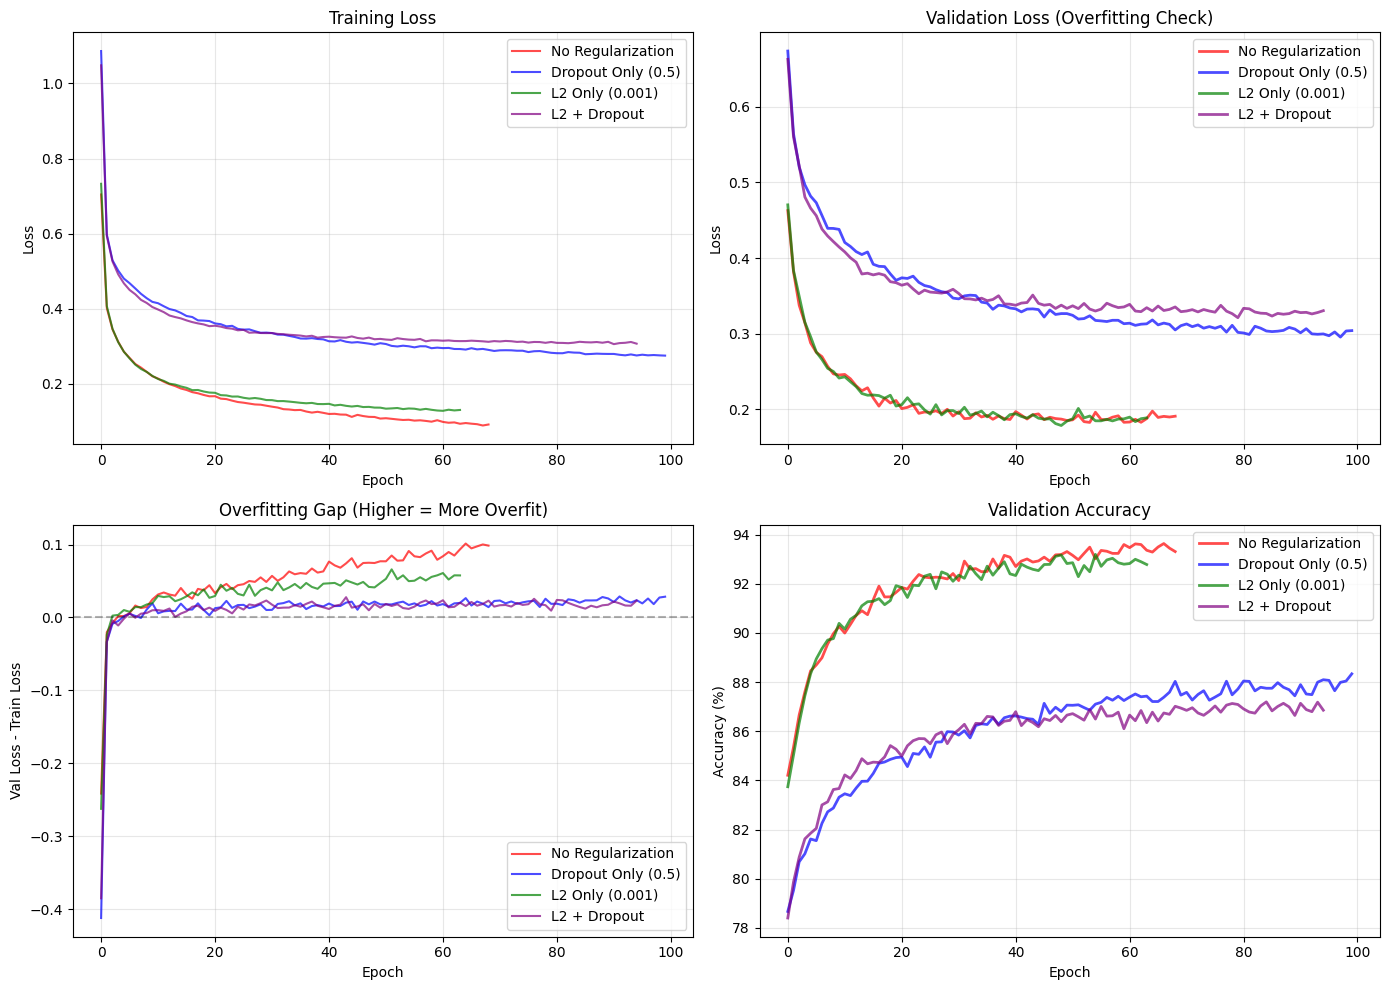


BRUTAL TRUTH:
Without regularization on 54 features, the model memorizes training data.
L2 + Dropout gives best generalization.
Notice: No regularization has LOW train loss but HIGH val loss = OVERFITTING
This is why regularization isn't optional for high-dimensional problems.


In [ ]:
fig, axes = plt.subplots(2,2, figsize=(14, 10))
colors = ['red', 'blue', 'green', 'purple']

for (name, (_, train_losses, _, _, _)), color in zip(results.items(), colors):
    axes[0, 0].plot(train_losses, label=name, alpha=0.7, color=color)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Validation Loss (KEY METRIC)
for (name, (_, _, val_losses, _, _)), color in zip(results.items(), colors):
    axes[0, 1].plot(val_losses, label=name, alpha=0.7, color=color, linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Validation Loss (Overfitting Check)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Training vs Validation Gap
for (name, (_, train_losses, val_losses, _, _)), color in zip(results.items(), colors):
    gap = [v - t for t, v in zip(train_losses, val_losses)]
    axes[1, 0].plot(gap, label=name, alpha=0.7, color=color)
axes[1, 0].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Val Loss - Train Loss')
axes[1, 0].set_title('Overfitting Gap (Higher = More Overfit)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Validation Accuracy
for (name, (_, _, _, _, val_accs)), color in zip(results.items(), colors):
    axes[1, 1].plot(val_accs, label=name, alpha=0.7, color=color, linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].set_title('Validation Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('covtype_regularization.png', dpi=150, bbox_inches='tight')
print("\nVisualization saved as 'covtype_regularization.png'")
plt.show()

print("\n" + "="*70)
print("BRUTAL TRUTH:")
print("="*70)
print("Without regularization on 54 features, the model memorizes training data.")
print("L2 + Dropout gives best generalization.")
print("Notice: No regularization has LOW train loss but HIGH val loss = OVERFITTING")
print("This is why regularization isn't optional for high-dimensional problems.")